# DevLog AI Comparative Baseline V3

## 1. Experiment overview

This notebook is the analytical record of the first official comparative baseline experiment. It compares two frozen conditions on three frozen questions, with three repetitions per question and condition:

- `DEVLOG`: the model receives frozen structured DevLog context.
- `AGENT_DIRECT`: the model reads the pinned repository through bounded read-only repository tools, without DevLog context.

The provider/model configuration was held constant. The collection completed all 18 planned observations and is classified as a **PARTIALLY_VALID_BASELINE**.

The analyzed attempt is `official-20260916T213831Z-deb74ef1`. The previous invalid collection is excluded. The dataset is restricted to `OFFICIAL_BASELINE` / `LIVE` observations.

The evaluation funnel is:

`provider execution -> structural validation -> evidence grounding -> semantic eligibility -> semantic evaluation`

A later-stage result is only meaningful when the preceding stage succeeded. `NOT_EVALUATED` is therefore not an incorrect result and must not be converted into 0% accuracy.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

dataset_path = Path("../../data/comparative-baseline/story0133-comparative-baseline-1.0.0/attempts/official-20260916T213831Z-deb74ef1/derived/observations.csv")
df = pd.read_csv(dataset_path)

required_columns = {
    "assignment_id", "run_id", "question_id", "condition",
    "repetition", "execution_class", "execution_mode",
    "structural_valid", "grounding_valid", "semantic_eligible",
    "semantic_correct", "primary_error",
}
assert required_columns <= set(df.columns)


## 2. Dataset validation

The checks below establish dataset shape, identity, completeness, and condition balance. They validate the existing derived dataset only; no raw or derived experimental data is modified.

In [2]:
assert len(df) == 18
assert df["assignment_id"].is_unique
assert df["run_id"].nunique() == 1
assert set(df["condition"]) == {"DEVLOG", "AGENT_DIRECT"}
assert set(df["execution_class"]) == {"OFFICIAL_BASELINE"}
assert set(df["execution_mode"]) == {"LIVE"}
assert int(df.isna().sum().sum()) == 0

dataset_summary = pd.DataFrame({
    "observations": df.groupby("condition").size(),
    "questions": df.groupby("condition")["question_id"].nunique(),
    "repetitions": df.groupby("condition")["repetition"].nunique(),
})
dataset_summary

,observations,questions,repetitions
condition,,,
AGENT_DIRECT,9,3,3
DEVLOG,9,3,3


## 3. Evaluation pipeline results

Structural validity and grounding validity are reported separately. Of the 18 observations, 7 DEVLOG observations were structurally valid and 2 were structurally invalid. AGENT_DIRECT produced no structurally valid final observations.

None of the 7 structurally valid observations passed evidence grounding. The other 11 observations have `grounding_valid = NOT_EVALUATED` because structural validation failed. All 18 have `semantic_eligible = NO` and `semantic_correct = NOT_EVALUATED`; this is not a semantic accuracy result.

In [3]:
funnel = pd.DataFrame({
    "Total": df.groupby("condition").size(),
    "Structural valid": df["structural_valid"].eq("YES").groupby(df["condition"]).sum(),
    "Grounding valid": df["grounding_valid"].eq("YES").groupby(df["condition"]).sum(),
    "Semantic eligible": df["semantic_eligible"].eq("YES").groupby(df["condition"]).sum(),
}).astype(int)
assert funnel.loc["DEVLOG"].tolist() == [9, 7, 0, 0]
assert funnel.loc["AGENT_DIRECT"].tolist() == [9, 0, 0, 0]
funnel

,Total,Structural valid,Grounding valid,Semantic eligible
condition,,,,
AGENT_DIRECT,9,0,0,0
DEVLOG,9,7,0,0


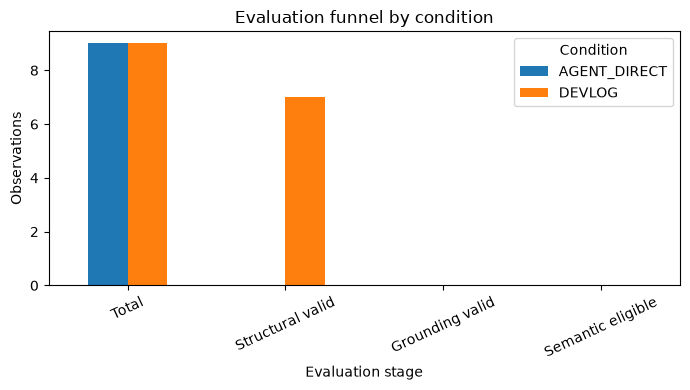

In [4]:
ax = funnel.T.plot(kind="bar", figsize=(7, 4))
ax.set_title("Evaluation funnel by condition")
ax.set_xlabel("Evaluation stage")
ax.set_ylabel("Observations")
ax.tick_params(axis="x", rotation=25)
ax.legend(title="Condition")
plt.tight_layout()
plt.show()

## 4. Failure-mode analysis

The original `primary_error` field is preserved as collected. It reports `INFRASTRUCTURE_FAILURE` for all 9 AGENT_DIRECT observations, `STRUCTURAL_FAILURE` for 2 DEVLOG observations, and `EVIDENCE_EXCERPT_MISMATCH` for 7 DEVLOG observations.

The `failure_category` below is a separate analytical classification from the post-collection offline validity investigation. It is not an original experimental field and does not overwrite `primary_error`. The investigation found no AGENT_DIRECT runtime infrastructure defect: 7 observations were legitimate bounded-agent failures and 2 were model-output failures. DEVLOG contained 2 genuine structural failures and 7 genuine grounding failures.

In [5]:
classification = {}
for question_id in ["CASE-01-COMPARATIVE", "CASE-03", "CASE-04"]:
    for repetition in [1, 2, 3]:
        classification[(question_id, "AGENT_DIRECT", repetition)] = (
            "MODEL_OUTPUT_FAILURE"
            if (question_id, repetition) in {("CASE-03", 2), ("CASE-04", 1)}
            else "LEGITIMATE_BOUNDED_AGENT_FAILURE"
        )
        classification[(question_id, "DEVLOG", repetition)] = (
            "GENUINE_MODEL_STRUCTURAL_FAILURE"
            if (question_id, repetition) in {("CASE-01-COMPARATIVE", 1), ("CASE-03", 1)}
            else "GENUINE_MODEL_GROUNDING_FAILURE"
        )

analysis_df = df.copy()
analysis_df["failure_category"] = [
    classification[(q, c, r)]
    for q, c, r in zip(analysis_df["question_id"], analysis_df["condition"], analysis_df["repetition"])
]
failure_counts = pd.crosstab(analysis_df["condition"], analysis_df["failure_category"])
failure_counts

failure_category,GENUINE_MODEL_GROUNDING_FAILURE,GENUINE_MODEL_STRUCTURAL_FAILURE,LEGITIMATE_BOUNDED_AGENT_FAILURE,MODEL_OUTPUT_FAILURE
condition,,,,
AGENT_DIRECT,0,0,7,2
DEVLOG,7,2,0,0


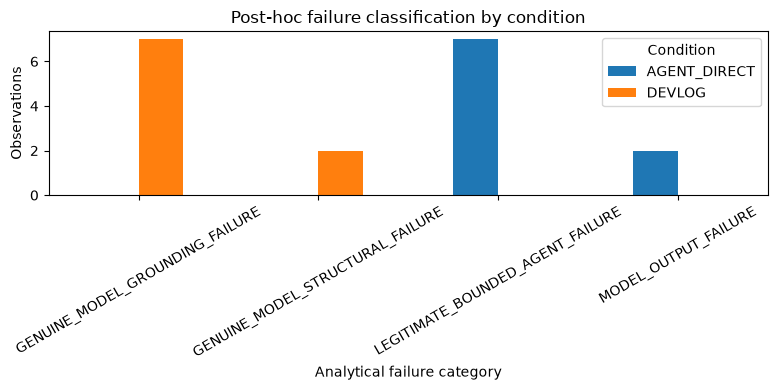

In [6]:
ax = failure_counts.T.plot(kind="bar", figsize=(8, 4))
ax.set_title("Post-hoc failure classification by condition")
ax.set_xlabel("Analytical failure category")
ax.set_ylabel("Observations")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Condition")
plt.tight_layout()
plt.show()

## 5. Resource observations

These descriptive medians are retained only to characterize the observed executions. They are not effectiveness measures and are confounded by the different points at which the conditions stopped.

In [7]:
resource_summary = (
    df.groupby("condition")[["input_tokens", "output_tokens", "latency_ms", "context_bytes", "repository_bytes"]]
    .median()
    .rename(columns={"input_tokens": "median_input_tokens", "output_tokens": "median_output_tokens", "latency_ms": "median_latency_ms", "context_bytes": "median_context_bytes", "repository_bytes": "median_repository_bytes"})
)
resource_summary

,median_input_tokens,median_output_tokens,median_latency_ms,median_context_bytes,median_repository_bytes
condition,,,,,
AGENT_DIRECT,3788.0,178.0,3344.0,0.0,7826.0
DEVLOG,8457.0,821.0,6286.0,31683.0,0.0


## 6. Limitations and conclusion

- The sample contains only 9 observations per condition, with 3 repetitions of each of 3 questions.
- No observation was semantically eligible, so semantic accuracy and the intended comparative effectiveness cannot be measured.
- AGENT_DIRECT observations ended before structural validation under the frozen bounded-agent constraints; the offline investigation attributes them to 7 legitimate bounded-agent failures and 2 model-output failures, not runtime infrastructure defects.
- DEVLOG produced 2 genuine structural failures and 7 genuine grounding failures.
- Resource observations are descriptive only because failure stage differs by condition.

This is a **partially valid baseline**, not a successful measurement of the original comparative hypothesis. It identifies different failure mechanisms and limitations in the experimental setup: DEVLOG reached structural validation but none of its evidence grounded, while AGENT_DIRECT produced no structurally valid final observations. The experiment does not demonstrate that DEVLOG is more or less effective than AGENT_DIRECT, and semantic accuracy must not be reported as 0%.